In [372]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
import warnings
from sklearn.preprocessing import LabelEncoder, StandardScaler
warnings.filterwarnings("ignore")

In [373]:
df = pd.read_csv("used_cars.csv")
df = pd.DataFrame(df)

In [374]:
df.head()

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
0,Ford,Utility Police Interceptor Base,2013,"51,000 mi.",E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,"$10,300"
1,Hyundai,Palisade SEL,2021,"34,742 mi.",Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,"$38,005"
2,Lexus,RX 350 RX 350,2022,"22,372 mi.",Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,None reported,NaN,"$54,598"
3,INFINITI,Q50 Hybrid Sport,2015,"88,900 mi.",Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,None reported,Yes,"$15,500"
4,Audi,Q3 45 S line Premium Plus,2021,"9,835 mi.",Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,None reported,NaN,"$34,999"


In [375]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4009 entries, 0 to 4008
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   brand         4009 non-null   object
 1   model         4009 non-null   object
 2   model_year    4009 non-null   int64 
 3   milage        4009 non-null   object
 4   fuel_type     3839 non-null   object
 5   engine        4009 non-null   object
 6   transmission  4009 non-null   object
 7   ext_col       4009 non-null   object
 8   int_col       4009 non-null   object
 9   accident      3896 non-null   object
 10  clean_title   3413 non-null   object
 11  price         4009 non-null   object
dtypes: int64(1), object(11)
memory usage: 376.0+ KB


In [376]:
df.describe()

,model_year
count,4009.000000
mean,2015.515590
std,6.104816
min,1974.000000
25%,2012.000000
50%,2017.000000
75%,2020.000000
max,2024.000000


In [377]:
df.isnull().sum()

brand             0
model             0
model_year        0
milage            0
fuel_type       170
engine            0
transmission      0
ext_col           0
int_col           0
accident        113
clean_title     596
price             0
dtype: int64

In [378]:
df.duplicated().sum()

np.int64(0)

### **Preprocessing**

Replace prefix

In [379]:
df['milage'] = df['milage'].str.replace(' mi.', '').str.replace(',', '').astype(int)
df['price'] = df['price'].str.replace('$', '').str.replace(',', '').astype(int)

Feature Extraction

In [380]:
# Create hp column
df['hp'] = df['engine'].str.extract(r'(\d+\.\d+)HP').astype(float, errors='ignore')

# Create engine displacement
df['engine displacement'] = df['engine'].str.extract(r'(\d+\.\d+)\s*L')
df['engine displacement'] = df['engine displacement'].fillna(df['engine'].str.extract(r'(\d+\.\d+)\s*LITER')[0])
df['engine displacement'] = df['engine displacement'].astype(float, errors='ignore')

# Is it V type or not
df['is_v_engine'] = df['engine'].str.contains(r'V\d+', case=False, na=False)

Cleaning the fuel_type feature

In [381]:
df['fuel_type'] = df['fuel_type'].str.strip().str.upper().replace({'PLUG-IN HYBRID': 'HYBRID', 'NOT SUPPORTED':'OTHER', '–':'OTHER'})

df['fuel_type'].value_counts()

fuel_type
GASOLINE         3309
HYBRID            228
E85 FLEX FUEL     139
DIESEL            116
OTHER              47
Name: count, dtype: int64

Cleaning the transmission feature

In [382]:
def classify_transmission(transmission):
    T = str(transmission).upper()
    
    if 'M/T' in T or 'MT' in T or 'MANUAL' in T:
        return 'M/T'
    elif 'A/T' in T or 'AT' in T or 'AUTOMATIC' in T:
        return 'A/T'
    elif 'CVT' in T or 'VARIABLE' in T or 'SINGLE-SPEED' in T:
        return 'CVT'
    else:
        return 'OTHER'
    
df['transmission'] = df['transmission'].apply(classify_transmission)

df['transmission'].unique()

array(['A/T', 'OTHER', 'M/T', 'CVT'], dtype=object)

Handle Missing Values

In [383]:
df['hp'] = df.groupby('brand')['hp'].transform(lambda x: x.fillna(x.mean()))

In [384]:
df.dropna(subset=['hp'], inplace=True)
most_common_fuel = df.groupby('brand')['fuel_type'].agg(lambda x: x.mode()[0] if not x.mode().empty else None)

df['fuel_type'] = df.apply(
    lambda row: most_common_fuel[row['brand']] if pd.isna(row['fuel_type']) else row['fuel_type'],
    axis=1
)

df['fuel_type'] = df['fuel_type'].fillna('OTHER')

In [385]:
most_common_displacement = df.groupby('brand')['engine displacement'].agg(lambda x: x.mode()[0] if not x.mode().empty else None)

df['engine displacement'] = df.apply(
    lambda row: most_common_displacement[row['brand']] if pd.isna(row['engine displacement']) else row['engine displacement'],
    axis=1
)

df['engine displacement'] = df['engine displacement'].fillna(df['engine displacement'].median())

Remove Outliers


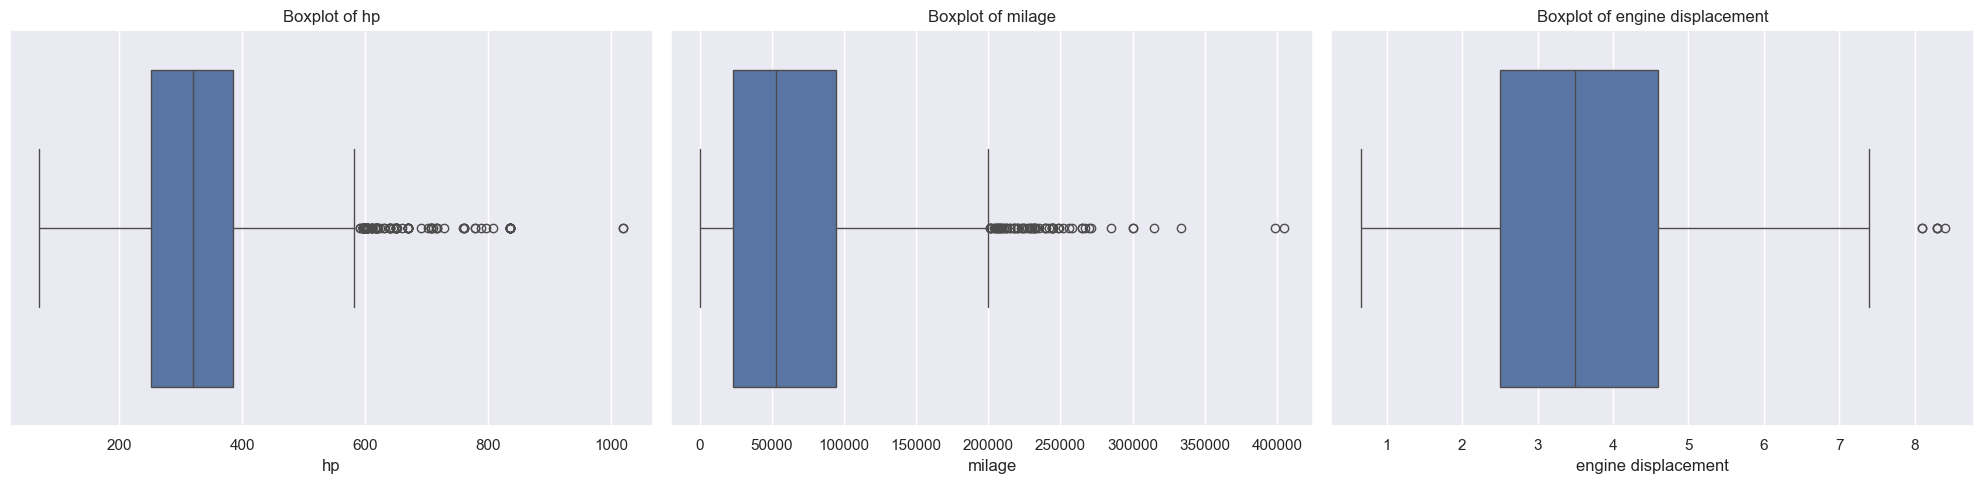

In [386]:
columns = ['hp', 'milage', 'engine displacement']

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
axes = axes.flatten()

for i, col in enumerate(columns):
    sns.boxplot(x=df[col], ax=axes[i])
    axes[i].set_title(f'Boxplot of {col}')
    axes[i].set_xlabel(f'{col}')

plt.tight_layout()
plt.show()

In [387]:
columns = ['engine displacement', 'hp', 'price', 'milage']
for col in columns:
    Q1 = df[col].quantile(0.25)  
    Q3 = df[col].quantile(0.75)   
    IQR = Q3 - Q1                    
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]

In [388]:
df.shape

(3606, 15)

Encoding Categorical Features


In [389]:
df['Accident_Impact'] = df['accident'].apply(lambda x: 1 if x == 'At least 1 accident or damage reported' else 0)


In [390]:
df['clean_title'] = df['clean_title'].apply(lambda x: 1 if x == 'Yes' else 0)


In [391]:
vis_df = df.copy()
vis_df.head()

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price,hp,engine displacement,is_v_engine,Accident_Impact
0,Ford,Utility Police Interceptor Base,2013,51000,E85 FLEX FUEL,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,A/T,Black,Black,At least 1 accident or damage reported,1,10300,300.000000,3.7,True,1
1,Hyundai,Palisade SEL,2021,34742,GASOLINE,3.8L V6 24V GDI DOHC,A/T,Moonlight Cloud,Gray,At least 1 accident or damage reported,1,38005,246.700000,3.8,True,1
2,Lexus,RX 350 RX 350,2022,22372,GASOLINE,3.5 Liter DOHC,A/T,Blue,Black,None reported,0,54598,303.659259,3.5,False,0
3,INFINITI,Q50 Hybrid Sport,2015,88900,HYBRID,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,A/T,Black,Black,None reported,1,15500,354.000000,3.5,True,0
4,Audi,Q3 45 S line Premium Plus,2021,9835,GASOLINE,2.0L I4 16V GDI DOHC Turbo,A/T,Glacier White Metallic,Black,None reported,0,34999,318.831250,2.0,False,0


In [392]:

def map_color(color):
    color = color.lower()

    if any(w in color for w in ['white', 'diamond', 'ivory', 'snow', 'pearl']):
        return 'White'
    if any(w in color for w in ['black', 'onyx', 'obsidian']):
        return 'Black'
    if any(w in color for w in ['blue','blu', 'navy', 'aqua', 'azure']):
        return 'Blue'
    if any(w in color for w in ['red', 'burgundy', 'maroon']):
        return 'Red'
    if any(w in color for w in ['silver', 'grey', 'gray', 'graphite', 'metal', 'granite']):
        return 'Silver/Gray'
    if any(w in color for w in ['green', 'olive']):
        return 'Green'
    if any(w in color for w in ['brown', 'bronze']):
        return 'Brown'
    if any(w in color for w in ['gold', 'beige', 'sand', 'champagne']):
        return 'Gold/Beige'
    if any(w in color for w in ['orange', 'yellow', 'go mango!', 'tan']):
        return 'Orange/Yellow'

    return 'Other'


df['int_col'] = df['int_col'].apply(map_color)

df['int_col'].value_counts()

int_col
Black            1951
Gold/Beige        520
Silver/Gray       465
Other             228
Brown             151
Red               117
White             112
Blue               32
Orange/Yellow      25
Green               5
Name: count, dtype: int64

In [393]:
#ext_col


df['ext_col'] = df['ext_col'].apply(map_color)

df['ext_col'].value_counts()

ext_col
Silver/Gray      918
Black            898
White            895
Blue             361
Red              268
Gold/Beige        76
Green             58
Orange/Yellow     57
Brown             39
Other             36
Name: count, dtype: int64

In [394]:
categorical_columns = ['fuel_type', 'transmission', 'is_v_engine','ext_col','int_col']

for cat_col in categorical_columns:
    encoder = LabelEncoder()
    df[cat_col] = encoder.fit_transform(df[cat_col])

Feature Engineering


In [395]:
df['Vehicle_Age'] = 2025 - df['model_year']


In [396]:
df['Mileage_per_Year'] = df.apply(
    lambda row: row['milage'] / row['Vehicle_Age'] if row['Vehicle_Age'] > 0 else row['milage'],
    axis=1
)

In [397]:
# Binning
df['Vehicle_Age_Bin'] = pd.qcut(df['Vehicle_Age'], q=4, labels=['New', 'Mid', 'Old', 'Very Old'])
df['Mileage_Bin'] = pd.qcut(df['milage'], q=4, labels=['Low', 'Medium', 'High', 'Very High'])

# One-hot encode
df = pd.get_dummies(df, columns=['Vehicle_Age_Bin', 'Mileage_Bin'], prefix=['Age', 'Milage'], drop_first=True, dtype=int)

Drop Unused Features


In [398]:
df.drop(['model', 'model_year', 'engine', 'milage', 'accident'], axis = 1, inplace = True)

In [399]:
df.isnull().sum()

brand                  0
fuel_type              0
transmission           0
ext_col                0
int_col                0
clean_title            0
price                  0
hp                     0
engine displacement    0
is_v_engine            0
Accident_Impact        0
Vehicle_Age            0
Mileage_per_Year       0
Age_Mid                0
Age_Old                0
Age_Very Old           0
Milage_Medium          0
Milage_High            0
Milage_Very High       0
dtype: int64

In [400]:
df.head()

,brand,fuel_type,transmission,ext_col,int_col,clean_title,price,hp,engine displacement,is_v_engine,Accident_Impact,Vehicle_Age,Mileage_per_Year,Age_Mid,Age_Old,Age_Very Old,Milage_Medium,Milage_High,Milage_Very High
0,Ford,1,0,0,0,1,10300,300.000000,3.7,1,1,12,4250.000000,0,1,0,1,0,0
1,Hyundai,2,0,6,8,1,38005,246.700000,3.8,1,1,4,8685.500000,0,0,0,1,0,0
2,Lexus,2,0,1,0,0,54598,303.659259,3.5,0,0,3,7457.333333,0,0,0,0,0,0
3,INFINITI,3,0,0,0,1,15500,354.000000,3.5,1,0,10,8890.000000,0,1,0,0,1,0
4,Audi,2,0,9,0,0,34999,318.831250,2.0,0,0,4,2458.750000,0,0,0,0,0,0


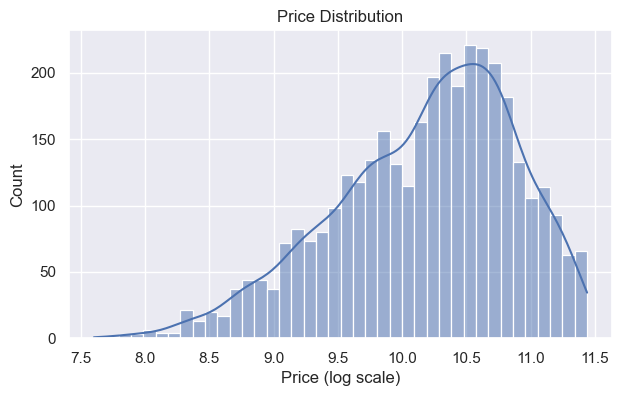

In [401]:
plt.figure(figsize=(7,4))
sns.histplot(np.log1p(df['price']), bins=40, kde=True)
plt.title('Price Distribution')
plt.xlabel('Price (log scale)')
plt.ylabel('Count')
plt.show()

<Axes: >

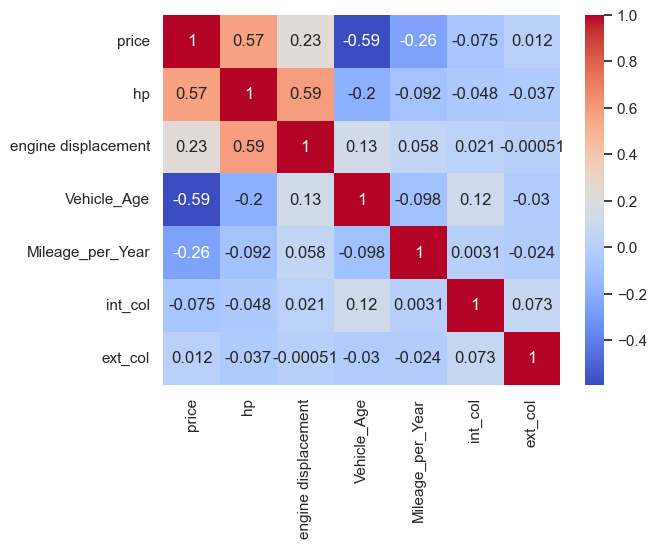

In [402]:
num_features = ['price','hp','engine displacement','Vehicle_Age','Mileage_per_Year','int_col','ext_col']
sns.heatmap(df[num_features].corr(), annot=True, cmap='coolwarm')

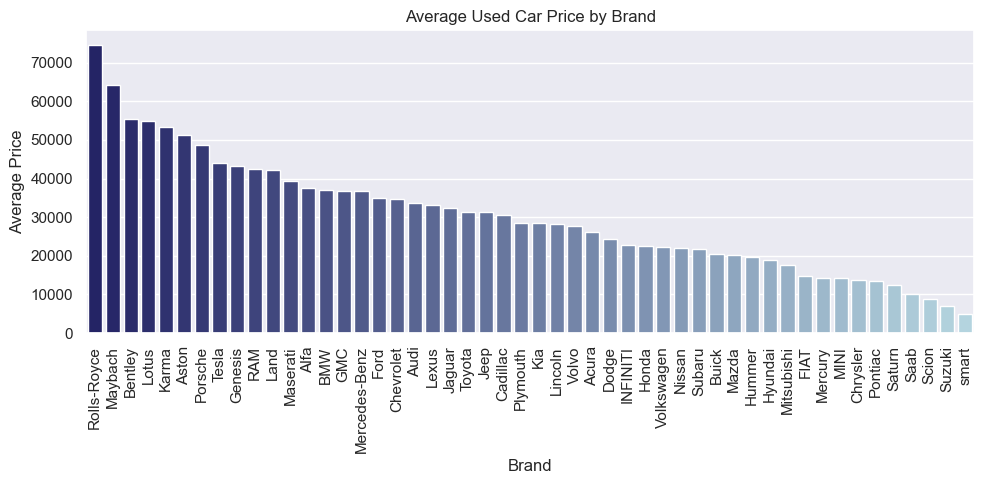

In [403]:
brand_avg_price = (
    vis_df.groupby('brand')['price']
      .mean()
      .sort_values(ascending=False)
)

plt.figure(figsize=(10,5))
sns.barplot(
    x=brand_avg_price.index,
    y=brand_avg_price.values,
    palette=sns.color_palette("blend:midnightblue,lightblue", n_colors=len(brand_avg_price)
))
plt.xticks(rotation=90)
plt.title("Average Used Car Price by Brand")
plt.xlabel("Brand")
plt.ylabel("Average Price")
plt.tight_layout()
plt.show()

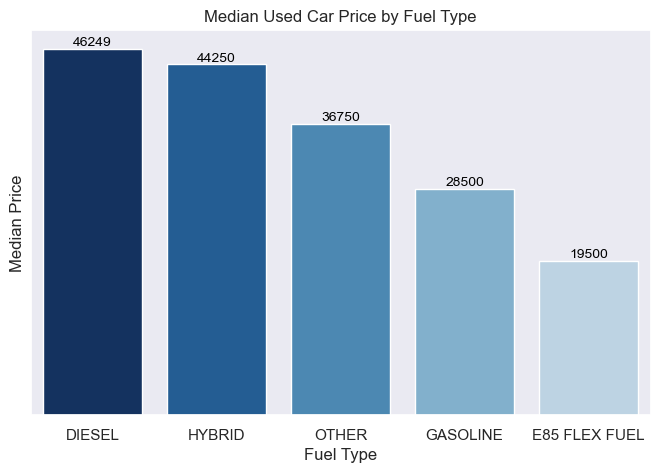

In [404]:
order = (
    vis_df.groupby('fuel_type')['price']
          .median()
          .sort_values(ascending=False)
          .index
)


medians = vis_df.groupby('fuel_type')['price'].median().loc[order]

# Color Grediant
cmap = plt.colormaps.get_cmap('Blues')
colors = [cmap(x) for x in np.linspace(1, 0.3, len(medians))]

plt.figure(figsize=(8,5))
ax = sns.barplot(
    x='fuel_type',
    y='price',
    data=vis_df,
    order=order,
    estimator=np.median,
    errorbar=None,
    palette=colors
)

plt.title("Median Used Car Price by Fuel Type")
plt.xlabel("Fuel Type")
ax.set_ylabel("Median Price")
ax.set_yticks([])   


for p in ax.patches:
    ax.annotate(
        f'{p.get_height():.0f}',
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center', va='bottom', fontsize=10, color='black'
    )

plt.show()

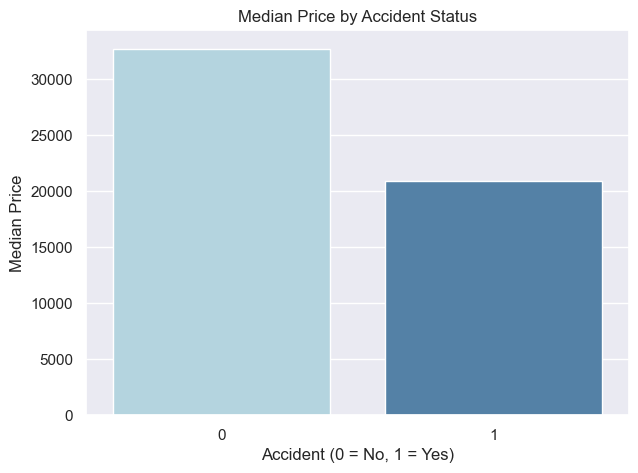

In [405]:
plt.figure(figsize=(7,5))

sns.barplot(
    x='Accident_Impact',
    y='price',
    data=vis_df,
    estimator=np.median,   
    errorbar=None,
    palette= ['lightblue','steelblue']
)

plt.title("Median Price by Accident Status")
plt.xlabel("Accident (0 = No, 1 = Yes)")
plt.ylabel("Median Price")
plt.show()

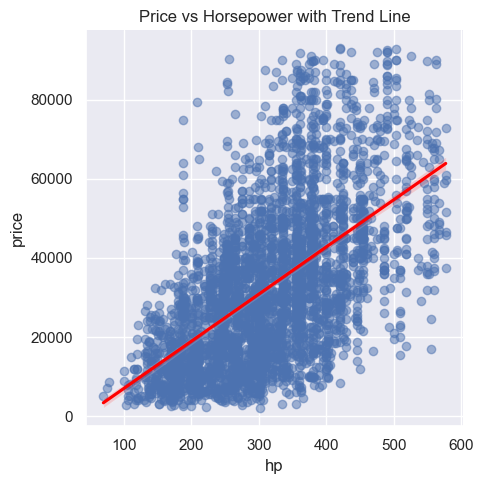

In [406]:
sns.lmplot(data=df, x='hp', y='price', line_kws={'color':'red'}, scatter_kws={'alpha':0.5})
plt.title('Price vs Horsepower with Trend Line')
plt.tight_layout()
plt.show()

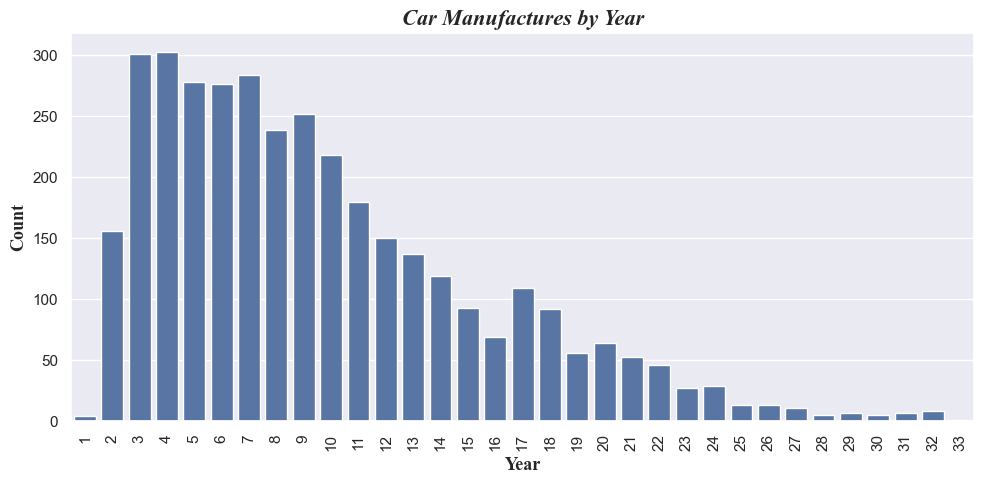

In [407]:
plt.figure(figsize=(10,5))
sns.countplot(data=df, x='Vehicle_Age', width=0.8)
plt.xticks(rotation=90)
plt.xlabel('Year', fontdict={'family': 'Times New Roman', 'size':13, 'weight': 'bold'})
plt.ylabel('Count', fontdict={'family': 'Times New Roman', 'size':13, 'weight': 'bold'})
plt.title('Car Manufactures by Year', fontdict={'family': 'Times New Roman', 'style': 'oblique', 'size':16, 'weight': 'bold'})
sns.set_style('darkgrid')
sns.set_theme('notebook')
plt.tight_layout()
plt.show()

In [408]:
df.brand.unique()

array(['Ford', 'Hyundai', 'Lexus', 'INFINITI', 'Audi', 'Acura', 'Tesla',
       'Land', 'Toyota', 'Lincoln', 'Jaguar', 'Dodge', 'Nissan',
       'Genesis', 'Chevrolet', 'BMW', 'Mercedes-Benz', 'Kia', 'Jeep',
       'Bentley', 'Honda', 'MINI', 'Porsche', 'Hummer', 'Chrysler',
       'Volvo', 'Cadillac', 'Maserati', 'Volkswagen', 'GMC', 'RAM',
       'Subaru', 'Alfa', 'Scion', 'Mitsubishi', 'Mazda', 'Saturn',
       'Buick', 'Aston', 'Lotus', 'Rolls-Royce', 'Pontiac', 'FIAT',
       'Karma', 'Saab', 'Mercury', 'Plymouth', 'smart', 'Maybach',
       'Suzuki'], dtype=object)

# **Model Building and Evaluation**

In [409]:
X = df.drop(['price'], axis = 1)
y = df['price']
y_log = np.log1p(y)


In [410]:
X.columns

Index(['brand', 'fuel_type', 'transmission', 'ext_col', 'int_col',
       'clean_title', 'hp', 'engine displacement', 'is_v_engine',
       'Accident_Impact', 'Vehicle_Age', 'Mileage_per_Year', 'Age_Mid',
       'Age_Old', 'Age_Very Old', 'Milage_Medium', 'Milage_High',
       'Milage_Very High'],
      dtype='object')

In [411]:
from sklearn.model_selection import train_test_split, GridSearchCV, KFold

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, make_scorer

In [412]:
X_train, X_test, y_train, y_test = train_test_split(X,y_log,test_size=0.2, random_state=42)

In [413]:
brand_target_mean = X_train.join(y_train).groupby('brand')['price'].mean()

X_train['brand_encoded'] = X_train['brand'].map(brand_target_mean)
X_test['brand_encoded'] = X_test['brand'].map(brand_target_mean)

X_test['brand_encoded'] = X_test['brand_encoded'].fillna(y_train.mean())

X_train = X_train.drop(columns=['brand'])
X_test = X_test.drop(columns=['brand'])

In [414]:
X_train.columns

Index(['fuel_type', 'transmission', 'ext_col', 'int_col', 'clean_title', 'hp',
       'engine displacement', 'is_v_engine', 'Accident_Impact', 'Vehicle_Age',
       'Mileage_per_Year', 'Age_Mid', 'Age_Old', 'Age_Very Old',
       'Milage_Medium', 'Milage_High', 'Milage_Very High', 'brand_encoded'],
      dtype='object')

In [415]:
cols3 = ['fuel_type', 'transmission', 'ext_col', 'int_col', 'clean_title', 'hp',
       'engine displacement', 'is_v_engine', 'Accident_Impact', 'Vehicle_Age',
       'Mileage_per_Year', 'Age_Mid', 'Age_Old', 'Age_Very Old',
       'Milage_Medium', 'Milage_High', 'Milage_Very High', 'brand_encoded']

for i in cols3:
    print("=="*25)
    print(X_train[i].value_counts().sort_values())



fuel_type
0      81
4      90
1     107
3     166
2    2440
Name: count, dtype: int64
transmission
1      55
2     282
3     298
0    2249
Name: count, dtype: int64
ext_col
6     25
2     33
4     42
5     48
3     58
7    216
1    294
0    717
9    720
8    731
Name: count, dtype: int64
int_col
4       3
5      24
1      28
9      87
7     101
2     123
6     179
8     375
3     416
0    1548
Name: count, dtype: int64
clean_title
0     387
1    2497
Name: count, dtype: int64
hp
324.00000     1
141.00000     1
357.00000     1
495.00000     1
456.00000     1
             ..
420.00000    49
335.81672    54
400.00000    54
355.00000    56
300.00000    82
Name: count, Length: 313, dtype: int64
engine displacement
2.10      1
1.00      1
4.50      1
7.40      1
1.70      1
1.20      2
7.00      2
5.80      2
7.30      2
6.80      2
6.75      2
6.10      2
5.90      3
2.80      3
6.30      4
2.20      5
5.20      5
0.65      5
3.90      7
1.30      8
2.90     12
1.40     13
4.30     14
5.40 

In [416]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [417]:
def adjusted_r2(r2, n, p):
    return 1 - (1 - r2) * (n - 1) / (n - p - 1)

In [418]:
models = {
    "LinearRegression": LinearRegression(),

    "DecisionTree": DecisionTreeRegressor(
        random_state=42
    ),

    "RandomForest": RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ),

    "SVR": SVR(
        kernel="rbf",
        C=100,
        gamma="scale"
    ),

    "XGBoost": XGBRegressor(
        n_estimators=500,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1
    )
}


In [419]:
n = X_test.shape[0]
p = X_test.shape[1]


**************************************************
Model : LinearRegression
R2 Score (Accuracy) : 0.7559
Adjusted R2        : 0.7496
MAE (Price)        : 7925.35
RMSE (Price)       : 11682.63
**************************************************



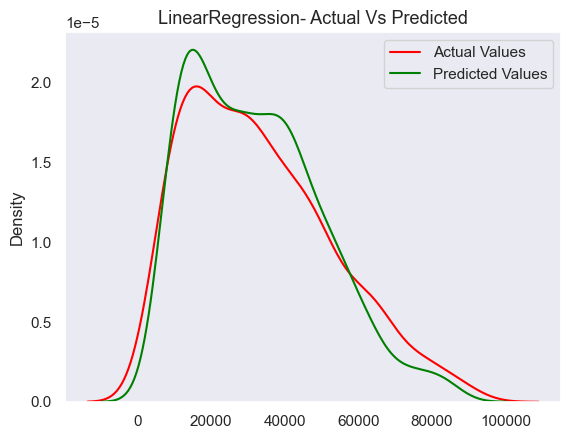


**************************************************
Model : DecisionTree
R2 Score (Accuracy) : 0.6783
Adjusted R2        : 0.6701
MAE (Price)        : 8278.29
RMSE (Price)       : 11951.97
**************************************************



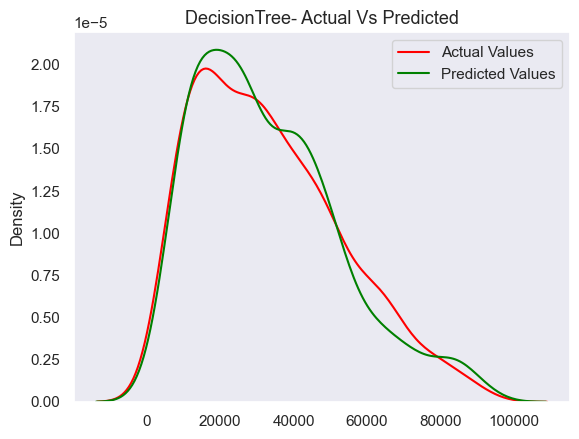


**************************************************
Model : RandomForest
R2 Score (Accuracy) : 0.8220
Adjusted R2        : 0.8174
MAE (Price)        : 5954.87
RMSE (Price)       : 9139.15
**************************************************



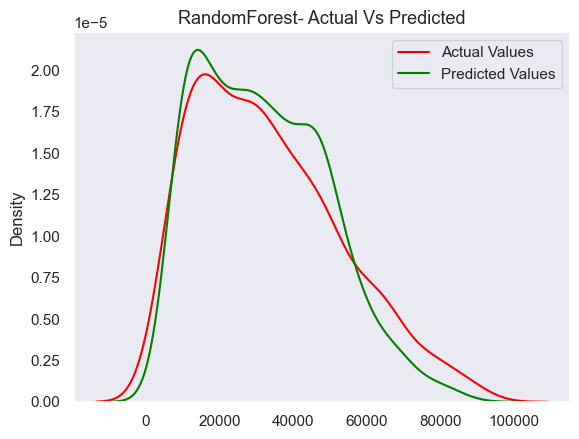


**************************************************
Model : SVR
R2 Score (Accuracy) : 0.6779
Adjusted R2        : 0.6696
MAE (Price)        : 8111.92
RMSE (Price)       : 12456.00
**************************************************



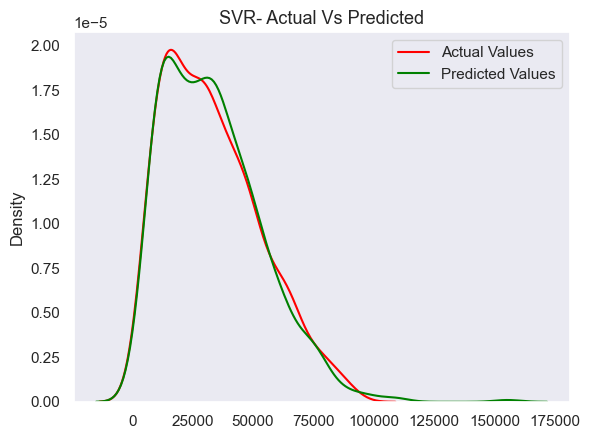


**************************************************
Model : XGBoost
R2 Score (Accuracy) : 0.8639
Adjusted R2        : 0.8604
MAE (Price)        : 5115.13
RMSE (Price)       : 8053.88
**************************************************



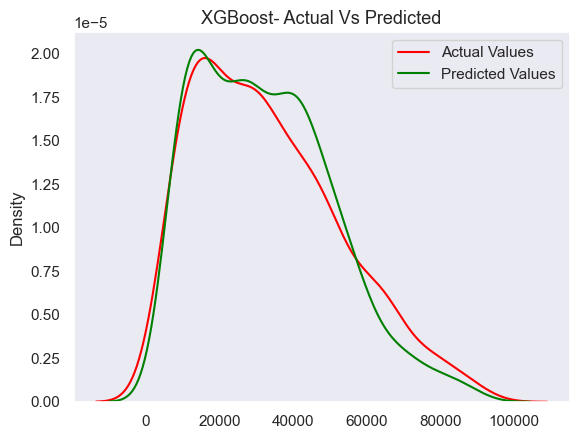

In [420]:

for name, model in models.items():

    print("\n" + "*" * 50)
    print(f"Model : {name}")
    print("=" * 50)

    # Train & Predict (correct handling)
    if name in ["LinearRegression", "SVR"]:
        model.fit(X_train_scaled, y_train)
        y_pred_log = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred_log = model.predict(X_test)

    # Convert back to real price
    y_pred = np.expm1(y_pred_log)
    y_test_real = np.expm1(y_test)

    # Metrics (real-world units)
    r2 = r2_score(y_test, y_pred_log)   # R2 stays on log scale
    mae = mean_absolute_error(y_test_real, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test_real, y_pred))
    adj_r2 = adjusted_r2(r2, n, p)

    # Print results
    print("================================================")
    print(f"R2 Score (Accuracy) : {r2:.4f}")
    print(f"Adjusted R2        : {adj_r2:.4f}")
    print(f"MAE (Price)        : {mae:.2f}")
    print(f"RMSE (Price)       : {rmse:.2f}")
    print("*" * 50)
    print()

    sns.kdeplot(y_test_real.values, color='red', label='Actual Values')
    sns.kdeplot(y_pred, color='green',label='Predicted Values')
    plt.title(f'{name}- Actual Vs Predicted', fontsize=13)
    plt.grid()
    plt.legend()
    plt.show()


In [ ]:
import joblib


# brand mapping (for Streamlit)
brand_mapping = (
    X.assign(price=y)
    .groupby("brand")["price"]
    .mean()
)

joblib.dump(brand_mapping, "brand_mapping.pkl")
joblib.dump(models["XGBoost"], "used_car_price_xgboost.pkl")
joblib.dump(X_train.columns.tolist(), "column.pkl")
joblib.dump(scaler, "scaler.pkl")          # optional but recommended

print("Model, scaler, and features saved successfully!")

Model, scaler, and features saved successfully!
